## Plotting flower and fruit data

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

Read the data file and set indexing to datetime. I am using the forJenny_IntensiveSurvey2025 dataset for now.

In [2]:
df = pd.read_csv('../data/raw/forJenny_IntensiveSurvey2025.csv') # Read the CSV file into a DataFrame
df['end'] = pd.to_datetime(df['end']) # Convert date column to datetime object
df.set_index('end', inplace=True) # Set the date column as the index of the DataFrame

Look at the data collected for a specific plant ID by replacing the plant ID with the sample of interest.

In [ ]:
individual_data = df[df['PlantID'] == 'PF0614']  # Type the plant ID that you want to see the data for. For example, 'PF0612' or 'PE0008'.
print(individual_data)  # Look at all rows for plant ID PE0008  

Q1: **How does the flowering count and fruit yield change along the season?**

I do an intital analysis where I collapses all individual plants into a single daily total,
where all flower vs fruit counts are summed together for each day the survey is performed and plotted against the date.

This is a good first step to see the overall seasonal trend of flower and fruits counts (combined).
The drop taking place on the 5th to 6th of June is due to a gap in the data where most plants have no data collected (NA). I might remove this part after consulting Hilde. 

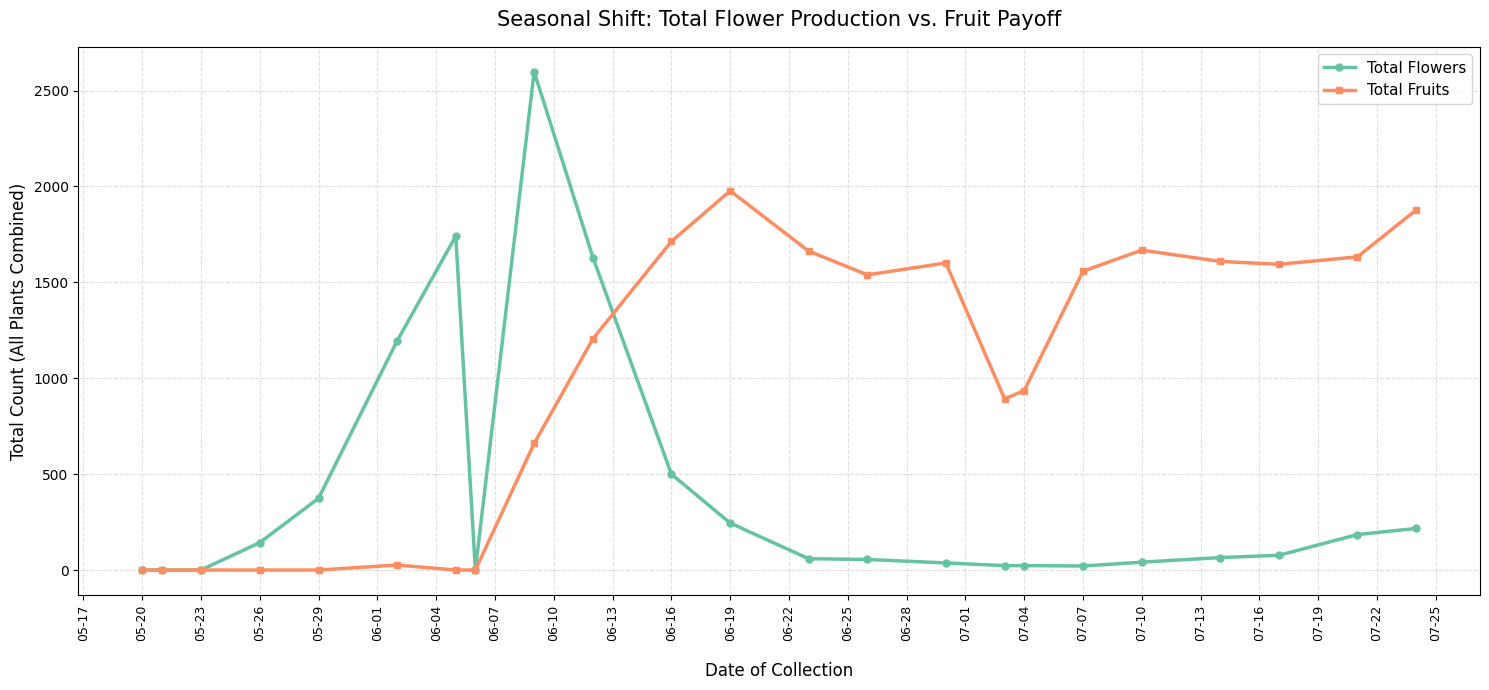

In [35]:


# 1. Group by the date index and calculate the sum for each day
daily_totals = df.groupby(df.index)[['Estim.Flowers.Nr', 'Estim.Fruits.Nr']].sum()

# 2. Set up a slightly wider plot to accommodate all the date text
fig, ax = plt.subplots(figsize=(15, 7))

# Plot Total Flowers
ax.plot(
    daily_totals.index, 
    daily_totals['Estim.Flowers.Nr'], 
    color='#66c2a5', 
    linewidth=2.5, 
    marker='o', 
    markersize=5, 
    label='Total Flowers'
)

# Plot Total Fruits
ax.plot(
    daily_totals.index, 
    daily_totals['Estim.Fruits.Nr'], 
    color='#fc8d62', 
    linewidth=2.5, 
    marker='s', 
    markersize=5, 
    label='Total Fruits'
)

# Tell the X-axis to place a tick mark on every third day
ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))

# Format how the date looks (e.g., '2026-06-01' or use '%b %d' for 'Jun 01')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))

# Rotate the text 90 degrees so they line up side-by-side like a barcode
plt.xticks(rotation=90, fontsize=9) 
# ---------------------------------

# 3. Customize labels and design
plt.title('Seasonal Shift: Total Flower Production vs. Fruit Payoff', fontsize=15, pad=15)
plt.xlabel('Date of Collection', fontsize=12, labelpad=15)
plt.ylabel('Total Count (All Plants Combined)', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(fontsize=11, loc='upper right')

# Use tight_layout but explicitly leave space at the bottom for the vertical dates
plt.tight_layout()
plt.savefig('total_seasonal_payoff_all_dates.png', dpi=300)
plt.show()

I then plot the data as box plots to see how the flower count vs fruit counts change over the season for different months. 

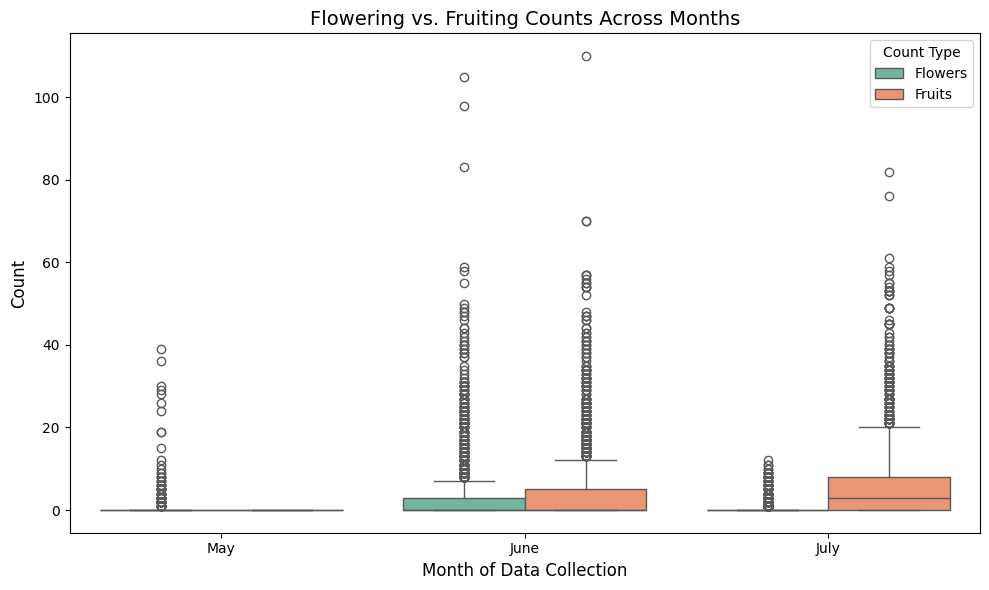

In [11]:
df['Month'] = df.index.month_name() # This will group the data into the 3 respective months of collection
# Reshape the data from wide format to long format
df_melted = df.melt(
    id_vars=['Month', 'PlantID'], 
    value_vars=['Estim.Flowers.Nr', 'Estim.Fruits.Nr'], 
    var_name='Count Type', 
    value_name='Count'
)

df_melted['Count Type'] = df_melted['Count Type'].map({
    'Estim.Flowers.Nr': 'Flowers',
    'Estim.Fruits.Nr': 'Fruits'
})
month_order = ['May', 'June', 'July'] 
df_melted['Month'] = pd.Categorical(df_melted['Month'], categories=month_order, ordered=True)

# Plot the overall seasonal trend of flower-to-fruit payoff (combined)
plt.subplots(figsize=(10, 6))
sns.boxplot(
    data=df_melted, 
    x='Month', 
    y='Count', 
    hue='Count Type', 
    palette='Set2'
)

plt.legend(
    title='Count Type', 
    loc='upper right' # Keeps the clean 'Flowers' and 'Fruits' labels with perfect colors!
)

plt.title('Flowering vs. Fruiting Counts Across Months', fontsize=14)
plt.xlabel('Month of Data Collection', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.tight_layout()
plt.savefig('flower_fruit_boxplot_aggregate.png')
plt.show()



**Does plants with high flower count on average have a higher yield of fruits?**

In order to visualize the efficiency for these high-performing individuals (plants with 10 or more flowers) I extract them from the dataset and then calculating a fruit-to-flower ratio which is the:
$$\text{Conversion Ratio} = \frac{\text{Total Estimated Fruits}}{\text{Total Estimated Flowers}}$$
A ratio of 1.0 means every single flower successfully turned into a fruit (100% efficiency), while a ratio of 0.5 means only half of the flowers made it to fruition.

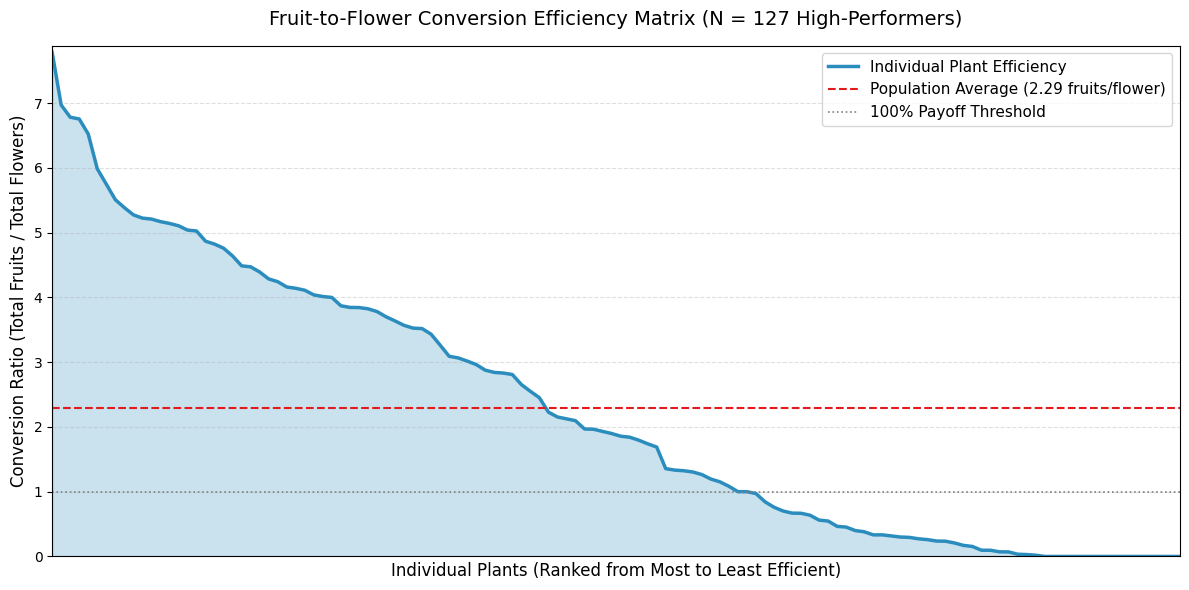

In [39]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load data and calculate totals per plant
df_high = pd.read_csv('../data/processed/high_flowering_plants.csv')
plant_totals = df_high.groupby('PlantID')[['Estim.Flowers.Nr', 'Estim.Fruits.Nr']].sum()

# 2. Calculate conversion ratio and sort from highest to lowest efficiency
plant_totals['Conversion_Ratio'] = plant_totals['Estim.Fruits.Nr'] / plant_totals['Estim.Flowers.Nr']
plant_totals = plant_totals.sort_values(by='Conversion_Ratio', ascending=False).reset_index()

# 3. Set up a clean, wide plot layout
plt.figure(figsize=(12, 6))

# Plot the exact ratio path for all 127 plants
plt.plot(
    plant_totals.index, 
    plant_totals['Conversion_Ratio'], 
    color='#2b8cbe', 
    linewidth=2.5, 
    label='Individual Plant Efficiency'
)

# Fill the area under the curve to visualize the population bulk
plt.fill_between(
    plant_totals.index, 
    plant_totals['Conversion_Ratio'], 
    color='#2b8cbe', 
    alpha=0.25
)

# 4. Add biological milestones / baselines
# Population average conversion rate
avg_ratio = plant_totals['Conversion_Ratio'].mean()
plt.axhline(avg_ratio, color='#e31a1c', linestyle='--', linewidth=1.5, 
            label=f'Population Average ({avg_ratio:.2f} fruits/flower)')

# The 100% boundary (1 fruit per 1 flower)
plt.axhline(1.0, color='gray', linestyle=':', linewidth=1.2, label='100% Payoff Threshold')

# 5. Clean layout & labels (no smudged text)
plt.title('Fruit-to-Flower Conversion Efficiency Matrix (N = 127 High-Performers)', fontsize=14, pad=15)
plt.xlabel('Individual Plants (Ranked from Most to Least Efficient)', fontsize=12)
plt.ylabel('Conversion Ratio (Total Fruits / Total Flowers)', fontsize=12)

# Keep the X-axis numeric ticks hidden so the text stays clean, but set limits explicitly
plt.xticks([]) 
plt.xlim(0, len(plant_totals) - 1)

# Ensure the graph leaves vertical breathing room if any plant over-performed (> 1.0)
plt.ylim(0, max(plant_totals['Conversion_Ratio'].max() + 0.1, 1.2))

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.legend(fontsize=11, loc='upper right')

plt.tight_layout()
plt.savefig('../data/processed/all_127_plants_efficiency.png', dpi=300)
plt.show()

**How does flowering late inseason effect the fruit yield?**

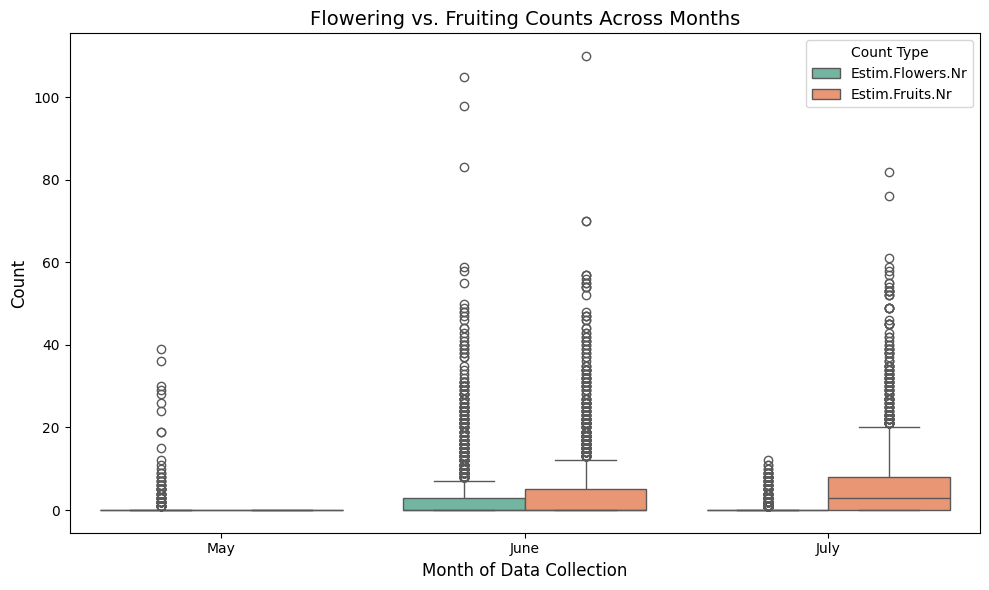

In [5]:
df['Month'] = df.index.month_name() # This will group your data into the 3 respective months of collection
# Reshape the data from wide format to long format
df_melted = df.melt(
    id_vars=['Month', 'PlantID'], 
    value_vars=['Estim.Flowers.Nr', 'Estim.Fruits.Nr'], 
    var_name='Count Type', 
    value_name='Count'
)

month_order = ['May', 'June', 'July'] 
df_melted['Month'] = pd.Categorical(df_melted['Month'], categories=month_order, ordered=True)

# Plot the overall seasonal trend of flower-to-fruit payoff (combined)
plt.subplots(figsize=(10, 6))
sns.boxplot(
    data=df_melted, 
    x='Month', 
    y='Count', 
    hue='Count Type', 
    palette='Set2'
)

plt.title('Flowering vs. Fruiting Counts Across Months', fontsize=14)
plt.xlabel('Month of Data Collection', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.tight_layout()
plt.savefig('flower_fruit_boxplot_aggregate.png')
plt.show()